### Importing libraries

In [2]:
#Importing libraries
import pyarrow.parquet as pq
import polars as pl
import os
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import xgboost as xgb
import shap
from sklearn.model_selection import GridSearchCV

### Loading dataset into memory through Polars

In [3]:
#Carregando dados na memória
default_path = "C:/Users/Italo/Desktop/UERJ/2026.1/cibersecurity/cybersecurity-uerj-2026-1"
parquet_path = os.path.join(default_path, "final-project/db/dnn.parquet")
print(parquet_path)
tabela_arrow = pq.read_table(parquet_path)
df = pl.from_arrow(tabela_arrow)

C:/Users/Italo/Desktop/UERJ/2026.1/cibersecurity/cybersecurity-uerj-2026-1\final-project/db/dnn.parquet


### Pre processing data

#### Droping unnecessary columns

In [4]:
#Dropando colunas do dataset
drop_columns = [
    "frame.time", 
    "ip.src_host", 
    "ip.dst_host", 
    "arp.dst.proto_ipv4", 
    "arp.opcode", 
    "arp.hw.size", 
    "arp.dst.proto_ipv4", 
    "arp.src.proto_ipv4", 
    "icmp.checksum", 
    "icmp.seq_le",
    "icmp.transmit_timestamp", 
    "icmp.unused", 
    "http.file_data", #Ponderar se deixar ou não
    "http.request.full_uri",
    "http.referer",
    "http.request.uri.query",
    "http.request.version",
    "http.tls_port",
    "tcp.dstport",
    "tcp.options",
    "tcp.srcport",
    "udp.port",
    "udp.time_delta",
    "dns.qry.type",
    "dns.retransmission",
    "mqtt.conack.flags",
    "mqtt.msg_decoded_as",
    "mqtt.msg",
    "mqtt.topic",
    "dns.qry.name.len",
    "mqtt.protoname"
]


df = df.drop(drop_columns)
df.head(20)


http.content_length,http.request.method,http.response,tcp.ack,tcp.ack_raw,tcp.checksum,tcp.connection.fin,tcp.connection.rst,tcp.connection.syn,tcp.connection.synack,tcp.flags,tcp.flags.ack,tcp.len,tcp.payload,tcp.seq,udp.stream,dns.qry.name,dns.qry.qu,dns.retransmit_request,dns.retransmit_request_in,mqtt.conflag.cleansess,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msgtype,mqtt.proto_len,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str
0.0,"""0.0""",0.0,1.0,3.1533e9,47892.0,0.0,0.0,0.0,1.0,18.0,1.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,1.0,3.44794516e8,16077.0,0.0,0.0,0.0,0.0,24.0,1.0,14.0,"""100c00044d5154540402003c0000""",1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,16.0,12.0,1.0,4.0,0.0,4.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,15.0,3.1533e9,62675.0,0.0,0.0,0.0,0.0,16.0,1.0,0.0,"""0""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,15.0,3.1533e9,54469.0,0.0,0.0,0.0,0.0,24.0,1.0,4.0,"""20020000""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,5.0,3.4479452e8,53812.0,0.0,0.0,0.0,0.0,24.0,1.0,41.0,"""3027001854656d7065726174757265…",15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,48.0,39.0,3.0,0.0,24.0,0.0,0.0,0.0,0.0,0,"""Normal"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,"""0.0""",0.0,6.0,3.44794521e8,62615.0,0.0,0.0,0.0,0.0,16.0,1.0,0.0,"""0""",59.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,1.0,1.0455e9,35755.0,0.0,0.0,0.0,0.0,16.0,1.0,0.0,"""0""",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""
0.0,"""0.0""",0.0,15.0,3.2943e9,35748.0,0.0,0.0,0.0,0.0,16.0,1.0,0.0,"""0""",5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,"""Normal"""


In [8]:
# Verificando qtd de dados na coluna
df.group_by("tcp.ack", "Attack_label").agg(pl.len().alias("count")).sort("count", descending=True)

tcp.ack,Attack_label,count
f64,i64,u32
0.0,1,282341
0.0,0,258706
1.0,0,253104
6.0,0,245995
5.0,0,169785
…,…,…
28127.0,0,1
29026.0,0,1
31167.0,0,1


#### Mapping labels to integers (column "http.request.method")

In [5]:
mapping_rm = {"0.0": 0.0,
                  "0": 0.0,
                  "GET": 1.0,
                  "POST": 2.0,
                  "TRACE": 3.0,
                  "OPTIONS": 4.0,
                  "PROPFIND": 5.0,
                  "PUT": 6.0,
                  "SEARCH": 7.0}

keys = pl.Series(mapping_rm.keys())
values = pl.Series(mapping_rm.values())

df = df.with_columns(
    pl.col("http.request.method").replace_strict(keys, values, default=0)
)

#### Translating labels to float (column "tcp.payload")

In [6]:

df = df.with_columns(
    pl.when(pl.col("tcp.payload") != "0")
      .then(pl.lit(0))
      .otherwise(pl.lit(1))
      .cast(pl.Float64)
      .alias("tcp.payload")
)


###  Parte de normalização dos dados do dataset (Rodar sem normalização primeiro pra ver como que tá)


In [15]:
#Normalizar coluna de content_length do HTTP

#Features importantes: 
# - http.request.method
# - http.content_length 
# - tcp.ack



# Min-Max http.content_length
df = df.with_columns(
    ((pl.col("http.content_length") - pl.col("http.content_length").min()) / 
     (pl.col("http.content_length").max() - pl.col("http.content_length").min()))
     #.cast(pl.Float64).round(5)
     .alias("http.content_length")
)


df = df.with_columns(
    ((pl.col("tcp.ack") - pl.col("tcp.ack").min()) / 
     (pl.col("tcp.ack").max() - pl.col("tcp.ack").min()))
     #.cast(pl.Float64).round(5)
     .alias("tcp.ack")
)

df = df.with_columns(
    ((pl.col("tcp.ack_raw") - pl.col("tcp.ack_raw").min()) / 
     (pl.col("tcp.ack_raw").max() - pl.col("tcp.ack_raw").min()))
     #.cast(pl.Float64).round(5)
     .alias("tcp.ack_raw")
)


# Min-Max http.content_length
df = df.with_columns(
    ((pl.col("tcp.checksum") - pl.col("tcp.checksum").min()) / 
     (pl.col("tcp.checksum").max() - pl.col("tcp.checksum").min()))
     #.cast(pl.Float64).round(5)
     .alias("tcp.checksum")
)


df = df.with_columns(
    ((pl.col("tcp.len") - pl.col("tcp.len").min()) / 
     (pl.col("tcp.len").max() - pl.col("tcp.len").min()))
     #.cast(pl.Float64).round(5)
     .alias("tcp.len")
)



df = df.with_columns(
    ((pl.col("dns.qry.name") - pl.col("dns.qry.name").min()) / 
     (pl.col("dns.qry.name").max() - pl.col("dns.qry.name").min()))
     #.cast(pl.Float64).round(5)
     .alias("dns.qry.name")
)






# # 4. (Opcional) Se você precisar devolver o resultado para o PyArrow:
# tabela_arrow_final = df_normalizado.to_arrow()

# # 5. Salvar o arquivo final de volta em Parquet usando o PyArrow
# pq.write_table(tabela_arrow_final, os.path.join("db/seu_arquivo_normalizado.parquet"))

# print("Processamento concluído com sucesso!")
# print(df_normalizado.head()) # Exibe as primeiras 5 linhas do resultado

### Rodando o algoritmo XGBoost (classificação binária)

--- Primeiras linhas do DataFrame Polars (X_pl) ---
shape: (3, 31)
┌───────────┬───────────┬───────────┬───────────┬───┬──────────┬───────────┬───────────┬───────────┐
│ http.cont ┆ http.requ ┆ http.resp ┆ tcp.ack   ┆ … ┆ mqtt.ver ┆ mbtcp.len ┆ mbtcp.tra ┆ mbtcp.uni │
│ ent_lengt ┆ est.metho ┆ onse      ┆ ---       ┆   ┆ ---      ┆ ---       ┆ ns_id     ┆ t_id      │
│ h         ┆ d         ┆ ---       ┆ f64       ┆   ┆ f64      ┆ f64       ┆ ---       ┆ ---       │
│ ---       ┆ ---       ┆ f64       ┆           ┆   ┆          ┆           ┆ f64       ┆ f64       │
│ f64       ┆ f64       ┆           ┆           ┆   ┆          ┆           ┆           ┆           │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪══════════╪═══════════╪═══════════╪═══════════╡
│ 0.0       ┆ 0.0       ┆ 0.0       ┆ 2.5319e-1 ┆ … ┆ 0.0      ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│           ┆           ┆           ┆ 0         ┆   ┆          ┆           ┆           ┆           │
│ 0.0       ┆ 0.0       

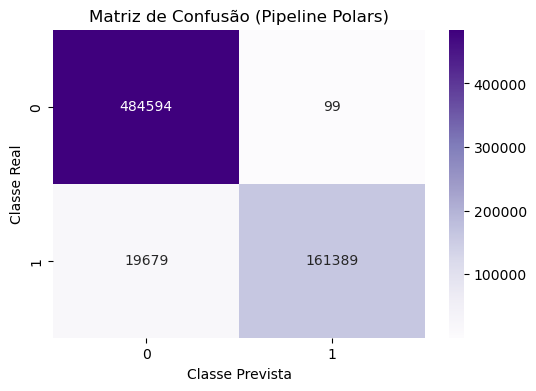

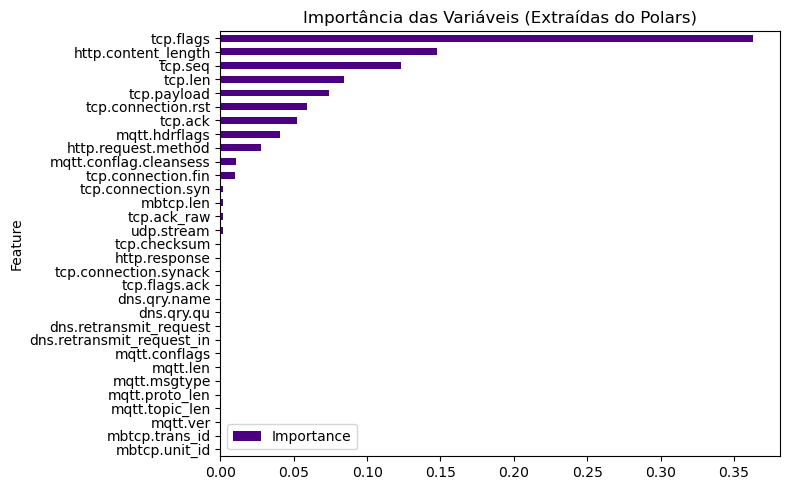

In [16]:


# =====================================================================
# 1. CARREGAMENTO E ESTRUTURAÇÃO DOS DADOS COM POLARS
# =====================================================================
# Importando dados de exemplo para o formato Polars

# Criando o DataFrame principal no Polars
X_pl = df.drop("Attack_label", "Attack_type")
y_pl = pl.Series("target", df["Attack_label"])



print("--- Primeiras linhas do DataFrame Polars (X_pl) ---")
print(X_pl.head(3))

# =====================================================================
# 2. DIVISÃO EM TREINO E TESTE
# =====================================================================
# Como o train_test_split do scikit-learn lida melhor com arrays numéricos,
# passamos os dados convertendo-os para NumPy de forma performática.
X_train, X_test, y_train, y_test = train_test_split(
    X_pl.to_numpy(),
    y_pl.to_numpy(),
    test_size=0.3,
    random_state=42,
    stratify=y_pl.to_numpy(),
)

# =====================================================================
# 3. CONFIGURAÇÃO E TREINAMENTO DO XGBOOST
# =====================================================================


scale_pos = 603558 / 1615643 

modelo = xgb.XGBClassifier(
    scale_pos_weight = scale_pos,
    n_estimators=100,
    device="cuda",
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="mlogloss",
)

# Treinando o modelo
modelo.fit(X_train, y_train)
print("\n[INFO] Modelo XGBoost treinado com sucesso utilizando Polars!")

# =====================================================================
# 4. PREVISÕES E AVALIAÇÃO
# =====================================================================
y_pred = modelo.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f"\nAcurácia Geral: {acuracia:.2%}\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred))

# =====================================================================
# 5. VISUALIZAÇÃO GRÁFICA
# =====================================================================
# Matriz de Confusão
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Purples",  # Só para diferenciar do padrão do pandas
    #xticklabels=df.target_names,
    #yticklabels=df.target_names,
)
plt.title("Matriz de Confusão (Pipeline Polars)")
plt.ylabel("Classe Real")
plt.xlabel("Classe Prevista")
plt.show()

# Importância das Features (mapeando os nomes das colunas originais do Polars)
plt.figure(figsize=(8, 5))
importances = modelo.feature_importances_
features = X_pl.columns

# Criando um gráfico de barras ordenado
pl.DataFrame({"Feature": features, "Importance": importances}).sort(
    "Importance", descending=True
).to_pandas().plot.barh(x="Feature", y="Importance", ax=plt.gca(), color="indigo")

plt.title("Importância das Variáveis (Extraídas do Polars)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Rodando o algoritmo XGBoost (classificação multivalorada)

#### Loading and structuring data with Polars


In [17]:
# =====================================================================
# 1. CARREGAMENTO E ESTRUTURAÇÃO DOS DADOS COM POLARS
# =====================================================================
# Criando o DataFrame principal de features (X)
X_pl = df.drop("Attack_label", "Attack_type")

# --- AJUSTE MULTICLASSE: Convertendo as strings em inteiros (0, 1, 2...) ---
# Usamos pl.Categorical e .to_physical() para fazer o mapeamento numérico rápido
y_categorical = df["Attack_type"].cast(pl.Categorical)
y_pl = y_categorical.to_physical()

# Guardamos o nome real das classes para usar nos gráficos e relatórios depois
nome_das_classes = y_categorical.cat.get_categories().to_list()
num_classes = len(nome_das_classes)

print(f"[INFO] Classes detectadas ({num_classes}): {nome_das_classes}")
print("--- Primeiras linhas do DataFrame Polars (X_pl) ---")


[INFO] Classes detectadas (15): ['Normal', 'MITM', 'Uploading', 'Ransomware', 'SQL_injection', 'DDoS_HTTP', 'DDoS_TCP', 'Password', 'Port_Scanning', 'Vulnerability_scanner', 'Backdoor', 'XSS', 'Fingerprinting', 'DDoS_UDP', 'DDoS_ICMP']
--- Primeiras linhas do DataFrame Polars (X_pl) ---


#### Setting data for training and test / configuring and training XGBoost algorithm

In [29]:
df.group_by("Attack_label").agg(pl.len().alias("count")).sort("count", descending=True)

Attack_label,count
i64,u32
0,1615643
1,603558


In [18]:
# =====================================================================
# 2. DIVISÃO EM TREINO E TESTE
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_pl.to_numpy(),
    y_pl.to_numpy(),
    test_size=0.3,
    random_state=42,
    stratify=y_pl.to_numpy(),  # Estratificação garante proporção igual de classes
)

# =====================================================================
# 3. CONFIGURAÇÃO E TREINAMENTO DO XGBOOST
# =====================================================================


modelo = xgb.XGBClassifier(
    device="cuda",
    tree_method="hist",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    objective="multi:softprob",  # <--- Define que o problema é multiclasse
    num_class=num_classes,       # <--- Informa a quantidade de classes do problema
    #eval_metric="mlogloss",
    eval_metric="aucpr",
)




# Treinando o modelo
modelo.fit(X_train, y_train)
print("\n[INFO] Modelo XGBoost Multiclasse treinado com sucesso utilizando Polars!")


# =====================================================================
# 4. PREVISÕES E AVALIAÇÃO
# =====================================================================
y_pred = modelo.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f"\nAcurácia Geral: {acuracia:.2%}\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred, target_names=nome_das_classes))




[INFO] Modelo XGBoost Multiclasse treinado com sucesso utilizando Polars!

Acurácia Geral: 96.21%

Relatório de Classificação Detalhado:
                       precision    recall  f1-score   support

               Normal       0.96      1.00      0.98    484693
                 MITM       1.00      0.32      0.48       364
            Uploading       0.93      0.68      0.79     11290
           Ransomware       1.00      0.77      0.87      3278
        SQL_injection       0.90      0.67      0.77     15361
            DDoS_HTTP       0.88      0.58      0.70     14973
             DDoS_TCP       1.00      1.00      1.00     15019
             Password       0.93      0.69      0.79     15046
        Port_Scanning       0.99      0.89      0.94      6769
Vulnerability_scanner       0.97      0.91      0.94     15033
             Backdoor       0.99      0.89      0.94      7459
                  XSS       0.96      0.71      0.82      4775
       Fingerprinting       1.00      0.14

#### Predicting values and assessing outcomes

In [ ]:

# =====================================================================
# 5. VISUALIZAÇÃO GRÁFICA
# =====================================================================
# Matriz de Confusão
plt.figure(figsize=(20, 12))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=nome_das_classes,  # <--- AJUSTE: Nome das classes no eixo X
    yticklabels=nome_das_classes,  # <--- AJUSTE: Nome das classes no eixo Y
)
plt.title("Matriz de Confusão Multiclasse (Pipeline Polars)")
plt.ylabel("Classe Real")
plt.xlabel("Classe Prevista")
plt.tight_layout()
plt.show()

# Importância das Features
plt.figure(figsize=(8, 5))
importances = modelo.feature_importances_
features = X_pl.columns

# Criando um gráfico de barras ordenado
pl.DataFrame({"Feature": features, "Importance": importances}).sort(
    "Importance", descending=True
).to_pandas().plot.barh(x="Feature", y="Importance", ax=plt.gca(), color="indigo")

plt.title("Importância das Variáveis (Extraídas do Polars)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Testando hiperparâmetros com GridSearchCV

In [ ]:
# =====================================================================
# 2. DIVISÃO EM TREINO E TESTE
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_pl.to_numpy(),
    y_pl.to_numpy(),
    test_size=0.3,
    random_state=42,
    stratify=y_pl.to_numpy(),  # Estratificação garante proporção igual de classes
)

# =====================================================================
# 3. CONFIGURAÇÃO E TREINAMENTO DO XGBOOST
# =====================================================================
# --- AJUSTE MULTICLASSE: Inclusão de objective e num_class ---
xgb = xgb.XGBClassifier()

param_grid = {
    'device': ["cuda"],
    'n_estimators': [10, 50, 100],
    'learning_rate': [0.1, 0.2, 0.3],
    'max_depth': [2, 5, 6],
    'random_state': [42],
    'min_child_weight': [2, 3, 4, 5],
    'objective': ["multi:softprob"],  # <--- Define que o problema é multiclasse
    'num_class': [num_classes],       # <--- Informa a quantidade de classes do problema
    'eval_metric': ["mlogloss"]
}

# Configurar o GridSearchCV
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=2, n_jobs=1, verbose=2)

# Treinar o GridSearchCV
grid_search.fit(X_train, y_train)

# Exibir os melhores hiperparâmetros
print(f"Melhores hiperparâmetros: {grid_search.best_params_}")

# Avaliar o modelo no conjunto de teste
best_model = grid_search.best_estimator_
accuracy = best_model.score(X_test, y_test)
print(f"Acurácia no conjunto de teste: {accuracy}")

Fitting 2 folds for each of 108 candidates, totalling 216 fits


c:\Users\Italo\anaconda3\envs\cibersec2_env\lib\site-packages\xgboost\training.py:183: UserWarning: [20:54:54] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END device=cuda, eval_metric=mlogloss, learning_rate=0.1, max_depth=2, min_child_weight=2, n_estimators=10, num_class=15, objective=multi:softprob, random_state=42; total time=   3.1s


c:\Users\Italo\anaconda3\envs\cibersec2_env\lib\site-packages\xgboost\training.py:183: UserWarning: [20:54:57] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END device=cuda, eval_metric=mlogloss, learning_rate=0.1, max_depth=2, min_child_weight=2, n_estimators=10, num_class=15, objective=multi:softprob, random_state=42; total time=   3.2s


...

[CV] END device=cuda, eval_metric=mlogloss, learning_rate=0.1, max_depth=2, min_child_weight=2, n_estimators=50, num_class=15, objective=multi:softprob, random_state=42; total time=  13.2s


c:\Users\Italo\anaconda3\envs\cibersec2_env\lib\site-packages\xgboost\training.py:183: UserWarning: [20:55:14] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END device=cuda, eval_metric=mlogloss, learning_rate=0.1, max_depth=2, min_child_weight=2, n_estimators=50, num_class=15, objective=multi:softprob, random_state=42; total time=  13.0s


c:\Users\Italo\anaconda3\envs\cibersec2_env\lib\site-packages\xgboost\training.py:183: UserWarning: [20:55:27] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\context.cc:203: XGBoost is not compiled with CUDA support.
  bst.update(dtrain, iteration=i, fobj=obj)


KeyboardInterrupt: 

### Testando o SHAP pra ver importancia das variaveis, mas sem sucesso

['Normal', 'MITM', 'Uploading', 'Ransomware', 'SQL_injection', 'DDoS_HTTP', 'DDoS_TCP', 'Password', 'Port_Scanning', 'Vulnerability_scanner', 'Backdoor', 'XSS', 'Fingerprinting', 'DDoS_UDP', 'DDoS_ICMP']
[INFO] Classes detectadas (15): ['Normal', 'MITM', 'Uploading', 'Ransomware', 'SQL_injection', 'DDoS_HTTP', 'DDoS_TCP', 'Password', 'Port_Scanning', 'Vulnerability_scanner', 'Backdoor', 'XSS', 'Fingerprinting', 'DDoS_UDP', 'DDoS_ICMP']
--- Primeiras linhas do DataFrame Polars (X_pl) ---

[INFO] Modelo XGBoost Multiclasse treinado com sucesso!

Acurácia Geral: 96.39%

Relatório de Classificação Detalhado:
                       precision    recall  f1-score   support

               Normal       0.96      1.00      0.98    484693
                 MITM       1.00      0.32      0.48       364
            Uploading       0.94      0.69      0.80     11290
           Ransomware       1.00      0.78      0.88      3278
        SQL_injection       0.92      0.67      0.78     15361
         

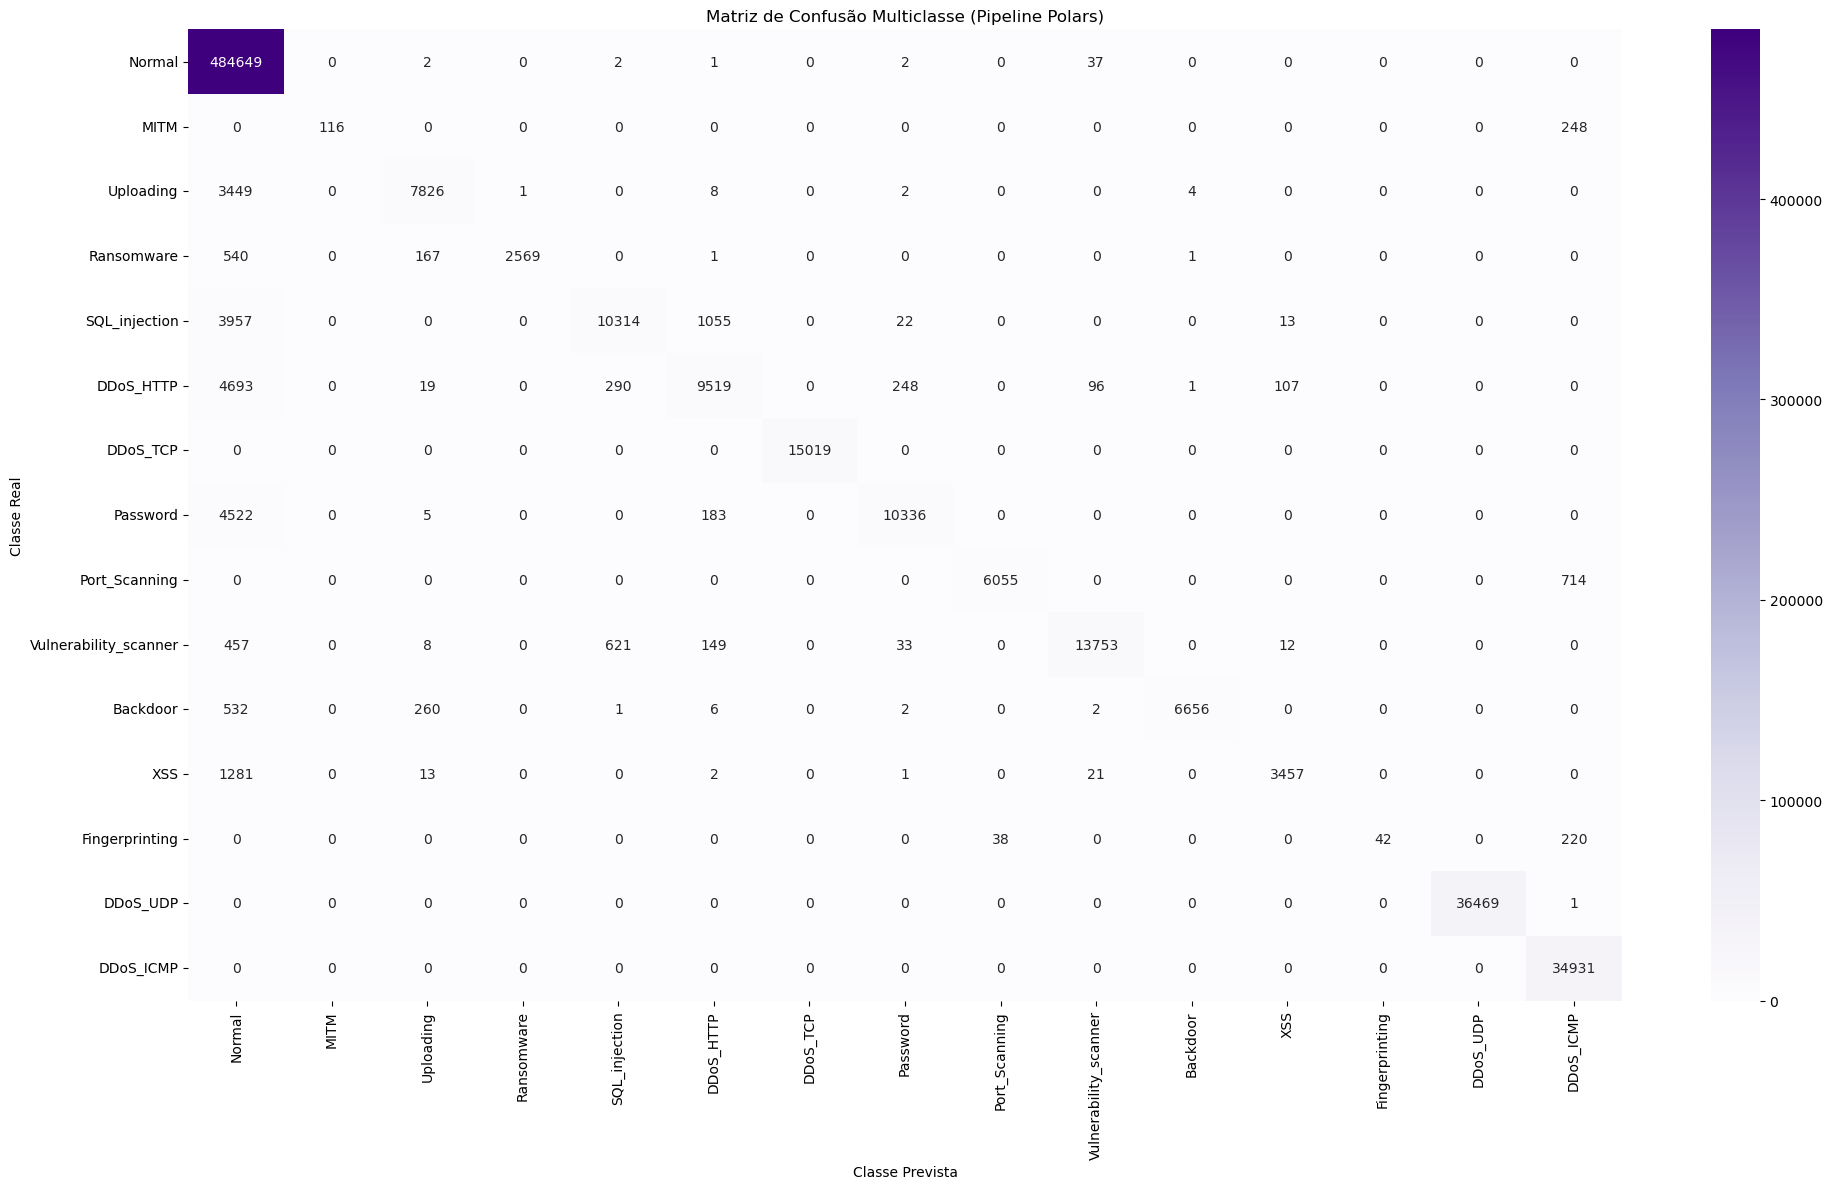

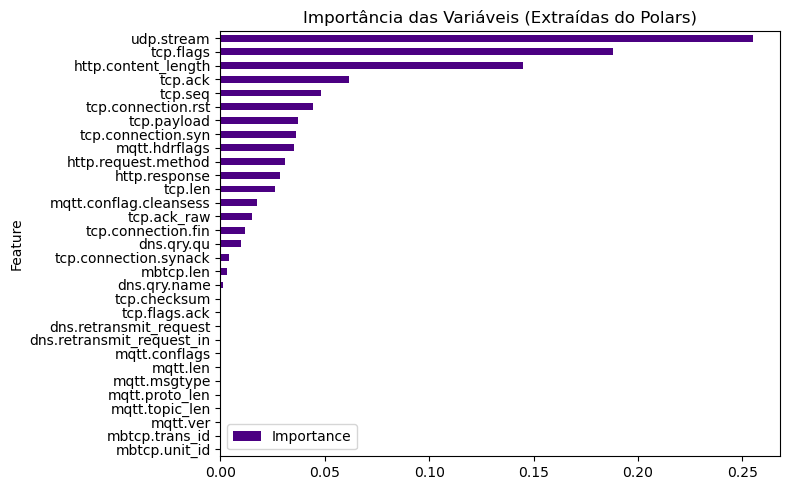


[INFO] Calculando os valores SHAP... (Isso pode levar alguns segundos)


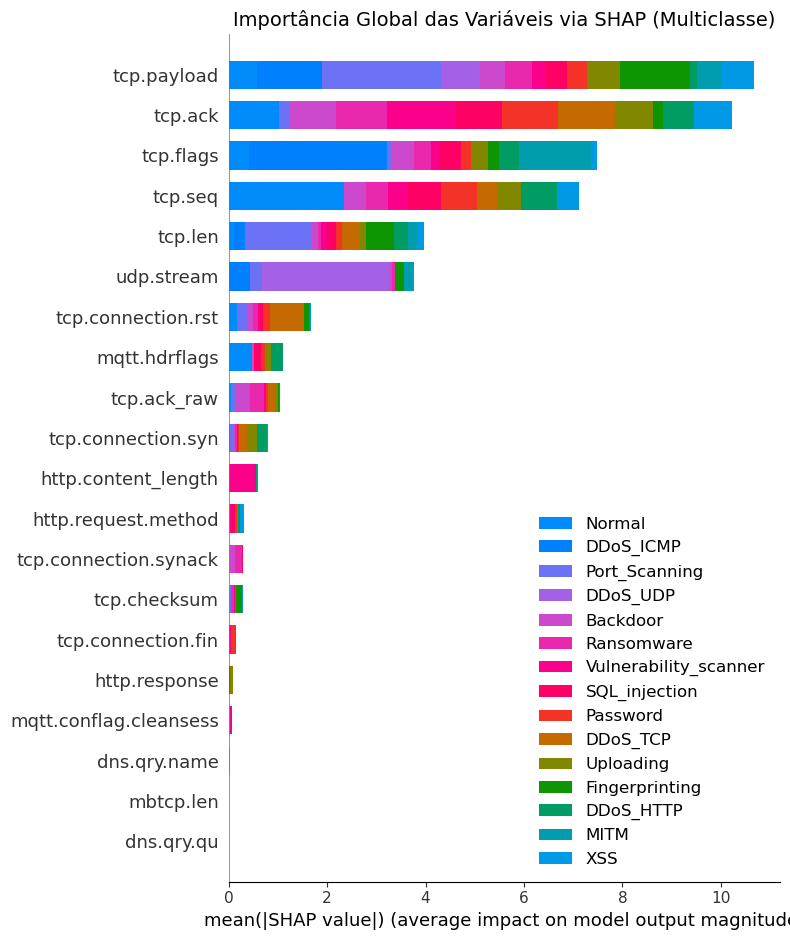

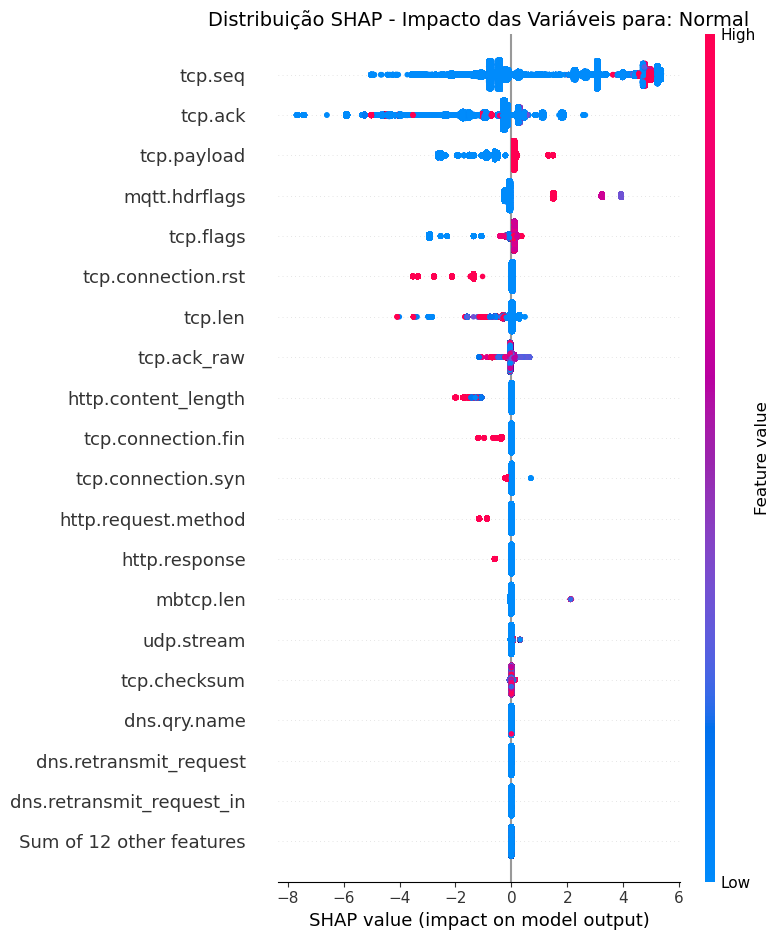

In [40]:
# =====================================================================
# 1. CARREGAMENTO E ESTRUTURAÇÃO DOS DADOS COM POLARS
# =====================================================================
X_pl = df.drop("Attack_label", "Attack_type")

y_categorical = df["Attack_type"].cast(pl.Categorical)
y_pl = y_categorical.to_physical()

nome_das_classes = y_categorical.cat.get_categories().to_list()
num_classes = len(nome_das_classes)

print(nome_das_classes)
# Guardamos o nome das colunas para mapear no SHAP mais tarde
features = X_pl.columns

print(f"[INFO] Classes detectadas ({num_classes}): {nome_das_classes}")
print("--- Primeiras linhas do DataFrame Polars (X_pl) ---")

# =====================================================================
# 2. DIVISÃO EM TREINO E TESTE
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_pl.to_numpy(),
    y_pl.to_numpy(),
    test_size=0.3,
    random_state=42,
    stratify=y_pl.to_numpy(),
)

# =====================================================================
# 3. CONFIGURAÇÃO E TREINAMENTO DO XGBOOST
# =====================================================================
modelo = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",
)

modelo.fit(X_train, y_train)
print("\n[INFO] Modelo XGBoost Multiclasse treinado com sucesso!")

# Nota: Certifique-se de gerar a variável y_pred no seu código antes do bloco abaixo:
y_pred = modelo.predict(X_test)

# =====================================================================
# 4. PREVISÕES E AVALIAÇÃO
# =====================================================================
y_pred = modelo.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f"\nAcurácia Geral: {acuracia:.2%}\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred, target_names=nome_das_classes))

# =====================================================================
# 5. VISUALIZAÇÃO GRÁFICA
# =====================================================================
# Matriz de Confusão
plt.figure(figsize=(20, 12))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=nome_das_classes,
    yticklabels=nome_das_classes,
)
plt.title("Matriz de Confusão Multiclasse (Pipeline Polars)")
plt.ylabel("Classe Real")
plt.xlabel("Classe Prevista")
plt.tight_layout()
plt.show()

# Importância das Features Tradicional
plt.figure(figsize=(8, 5))
importances = modelo.feature_importances_

pl.DataFrame({"Feature": features, "Importance": importances}).sort(
    "Importance", descending=True
).to_pandas().plot.barh(x="Feature", y="Importance", ax=plt.gca(), color="indigo")

plt.title("Importância das Variáveis (Extraídas do Polars)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# =====================================================================
# 6. IMPLEMENTAÇÃO DO SHAP (MULTICLASSE)
# =====================================================================
print("\n[INFO] Calculando os valores SHAP... (Isso pode levar alguns segundos)")


# --- BULLETPROOF FIX FOR THE STR TO FLOAT BUG ---
import json

try:
    # Access internal configurations of the trained XGBoost booster
    config = json.loads(modelo.get_booster().save_config())
    raw_score = config["learner"]["learner_model_param"]["base_score"]
    
    if isinstance(raw_score, str):
        # Clean out brackets and spaces
        cleaned = raw_score.replace("[", "").replace("]", "").strip()
        # Take the first value if it's a comma-separated list
        first_val = cleaned.split(",")[0].strip()
        
        # Convert to float and override the parameter safely
        clean_score = float(first_val)
        modelo.get_booster().set_param({"base_score": clean_score})
except Exception as e:
    print(f"[Aviso] Falha ao ajustar o base_score automaticamente: {e}")


# 1. Inicializa o explicador otimizado para árvores (XGBoost)
explainer = shap.TreeExplainer(modelo)

# 2. Calcula os valores SHAP para a base de teste
shap_values = explainer(X_test)


# --- GRÁFICO 1 CORRIGIDO: Importância Global Multiclasse ---
plt.figure(figsize=(12, 8))

# Extraímos a matriz bruta de valores SHAP (.values) para converter para a lista esperada
shap_values_matrix = [shap_values.values[:, :, i] for i in range(num_classes)]

# Usamos summary_plot que processa a matriz multiclasse perfeitamente
shap.summary_plot(
    shap_values_matrix, 
    X_test, 
    feature_names=features, 
    plot_type="bar", 
    class_names=nome_das_classes,
    max_display=20,
    show=False
)

plt.title("Importância Global das Variáveis via SHAP (Multiclasse)", fontsize=14)
plt.tight_layout()
plt.show()

# # 3. Vincula os nomes das colunas vindas do Polars para o gráfico ficar legível
# shap_values.feature_names = features

# # --- GRÁFICO 1: Importância Global SHAP (Barras Coloridas por Classe) ---
# # Em problemas multiclasse, este gráfico de barras mostra o impacto da variável
# # dividido por cada tipo de ataque (cada classe ganha uma cor).
# plt.figure(figsize=(12, 8))
# plt.title("Importância Global das Variáveis via SHAP (Multiclasse)", fontsize=14)
# shap.plots.bar(shap_values, max_display=15, show=False)
# plt.legend(labels=nome_das_classes, loc="lower right")
# plt.tight_layout()
# plt.show()

# --- GRÁFICO 2: Comportamento das Variáveis para uma Classe Específica ---
# Para ver se valores altos/baixos ajudam ou atrapalham, precisamos escolher
# UMA classe por vez no SHAP multiclasse usando o fatiamento: shap_values[:, :, classe_id]
classe_alvo_id = 0  # <--- Altere o índice (0, 1, 2...) para analisar o ataque desejado
nome_da_classe_alvo = nome_das_classes[classe_alvo_id]

# 1. Isolamos os valores SHAP da classe específica
shap_valores_classe = shap_values[:, :, classe_alvo_id]

# 2. Reatribuímos os nomes das features vindas do Polars para este objeto específico
shap_valores_classe.feature_names = features

# 3. Geramos o gráfico beeswarm atualizado
plt.figure(figsize=(12, 8)) # Aumentei um pouco a largura para não cortar os nomes longos
shap.plots.beeswarm(shap_valores_classe, max_display=20, show=False)

plt.title(f"Distribuição SHAP - Impacto das Variáveis para: {nome_da_classe_alvo}", fontsize=14)
plt.tight_layout()
plt.show()

### Testando se o CUDA tá funcionando com XGBoost

In [19]:
import xgboost as xgb
from sklearn.datasets import make_classification

# Generate dummy classification data
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# Set the device to 'cuda'
model = xgb.XGBClassifier(
    tree_method="hist",
    device="cuda", 
    n_estimators=20
)

model.fit(X, y)
print("SUCCESS: Custom Windows 10 CUDA build is working perfectly!")

SUCCESS: Custom Windows 10 CUDA build is working perfectly!


### END!